In [ ]:
import pandas as pd
import numpy as np
import warnings
import os
import json
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    RandomForestRegressor,
    StackingRegressor,
    VotingRegressor
)
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.model_selection import (
    KFold, cross_val_score, cross_val_predict, train_test_split
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

TRAIN_PATH   = 'train.csv'
TEST_PATH    = 'test_x.csv'
TARGET       = 'bilissel_performans_skoru'
ID_COL       = 'id'
RANDOM_STATE = 42
N_FOLDS      = 5
OUTPUT_DIR   = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

EXTRA_LIBS = {}
try:
    import lightgbm as lgb
    EXTRA_LIBS['lgb'] = lgb
    print("LightGBM mevcut")
except ImportError:
    print("LightGBM yok  →  pip install lightgbm")

try:
    import xgboost as xgb
    EXTRA_LIBS['xgb'] = xgb
    print("XGBoost mevcut")
except ImportError:
    print("XGBoost yok   →  pip install xgboost")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print("Optuna mevcut")
except ImportError:
    HAS_OPTUNA = False
    print("Optuna yok    →  pip install optuna")

✅ LightGBM mevcut
✅ XGBoost mevcut
✅ Optuna mevcut


In [ ]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

print(f"Train shape : {train_raw.shape}")
print(f"Test shape  : {test_raw.shape}")
print(f"Target range: [{train_raw[TARGET].min():.2f}, {train_raw[TARGET].max():.2f}]")
print(f"Target mean : {train_raw[TARGET].mean():.4f}")
print(f"Target std  : {train_raw[TARGET].std():.4f}")
print("Cell 2 tamamlandı")
train_raw.head(3)

Train shape : (56000, 24)
Test shape  : (24000, 23)
Target range: [0.00, 10.00]
Target mean : 5.9131
Target std  : 2.2318
✅ Cell 2 tamamlandı


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276


In [24]:
missing_train = train_raw.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print("Eksik Değerler:")
print(missing_train.to_string())

Eksik Değerler:
kronotip                 1968
vucut_kitle_indeksi      1752
stres_skoru              1715
uyku_oncesi_kafein_mg    1463
meslek                   1378
ruh_sagligi_durumu       1096


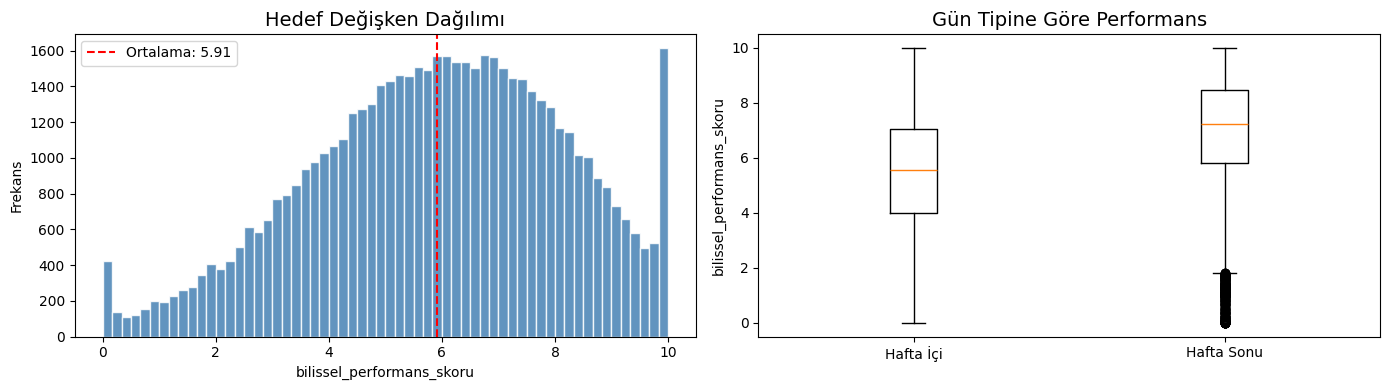

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_raw[TARGET], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Hedef Değişken Dağılımı', fontsize=14)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frekans')
axes[0].axvline(train_raw[TARGET].mean(), color='red', linestyle='--', label=f'Ortalama: {train_raw[TARGET].mean():.2f}')
axes[0].legend()

axes[1].boxplot([train_raw[train_raw['gun_tipi']=='Hafta ici'][TARGET],
                 train_raw[train_raw['gun_tipi']=='Hafta sonu'][TARGET]],
                labels=['Hafta İçi', 'Hafta Sonu'])
axes[1].set_title('Gün Tipine Göre Performans', fontsize=14)
axes[1].set_ylabel(TARGET)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

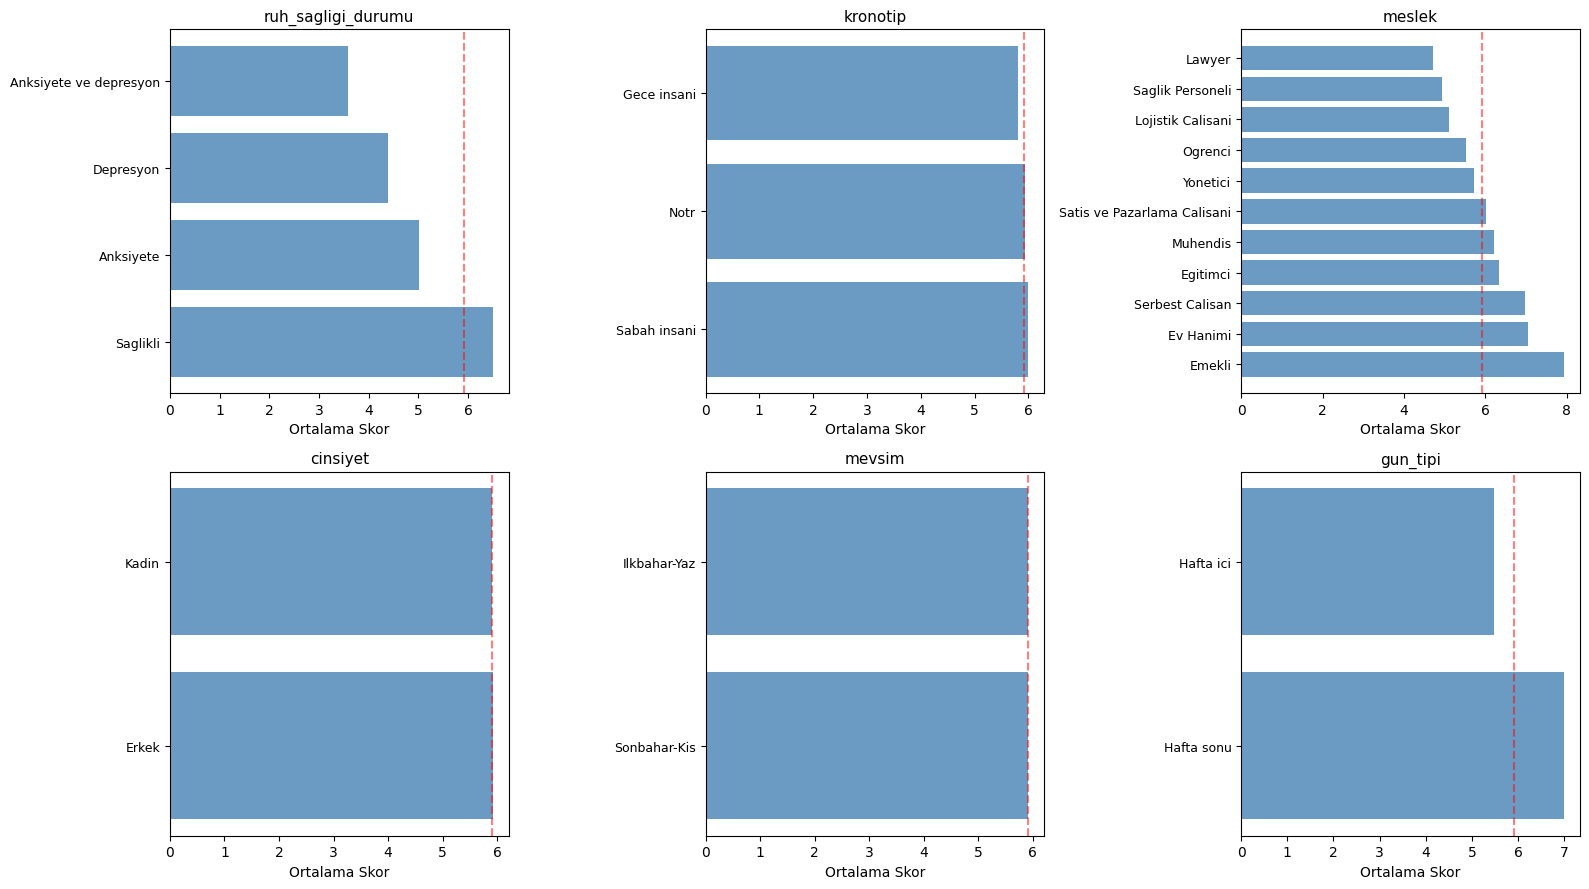

In [26]:
cat_cols = ['ruh_sagligi_durumu', 'kronotip', 'meslek', 'cinsiyet', 'mevsim', 'gun_tipi']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, cat_cols):
    data = train_raw.dropna(subset=[col])
    order = data.groupby(col)[TARGET].mean().sort_values(ascending=False).index
    means = data.groupby(col)[TARGET].mean().reindex(order)
    ax.barh(range(len(means)), means.values, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(means)))
    ax.set_yticklabels(means.index, fontsize=9)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Ortalama Skor')
    ax.axvline(train_raw[TARGET].mean(), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'categorical_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

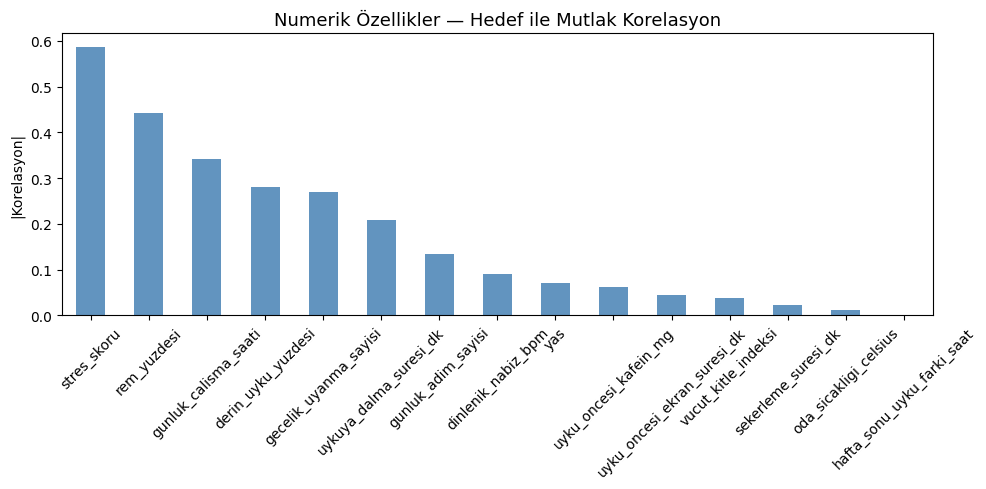

stres_skoru                    0.586676
rem_yuzdesi                    0.442999
gunluk_calisma_saati           0.342112
derin_uyku_yuzdesi             0.280006
gecelik_uyanma_sayisi          0.270349
uykuya_dalma_suresi_dk         0.207349
gunluk_adim_sayisi             0.134042
dinlenik_nabiz_bpm             0.089389
yas                            0.070659
uyku_oncesi_kafein_mg          0.062387
uyku_oncesi_ekran_suresi_dk    0.044631
vucut_kitle_indeksi            0.037990
sekerleme_suresi_dk            0.023683
oda_sicakligi_celsius          0.011992
hafta_sonu_uyku_farki_saat     0.001648


In [27]:
num_cols_train = train_raw.select_dtypes(include='number').columns.tolist()
num_cols_train = [c for c in num_cols_train if c not in [ID_COL, TARGET]]

corrs = train_raw[num_cols_train].corrwith(train_raw[TARGET]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
corrs.plot(kind='bar', ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Numerik Özellikler — Hedef ile Mutlak Korelasyon', fontsize=13)
ax.set_ylabel('|Korelasyon|')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'numeric_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

print(corrs.to_string())

In [ ]:

class SleepPerformanceFeatureEngineerV3(BaseEstimator, TransformerMixin):

    RSH_MAP      = {'Saglikli': 3, 'Anksiyete': 2,
                    'Depresyon': 1, 'Anksiyete ve depresyon': 0}
    KRONOTIP_MAP = {'Sabah insani': 2, 'Notr': 1, 'Gece insani': 0}
    SMOOTHING    = 10

    def fit(self, X, y=None):
        df = X.copy()

        self.numeric_medians_ = {
            c: df[c].median()
            for c in df.select_dtypes(include='number').columns
        }
        self.cat_modes_ = {}
        for c in ['ruh_sagligi_durumu', 'kronotip', 'meslek',
                  'ulke', 'cinsiyet', 'mevsim', 'gun_tipi']:
            self.cat_modes_[c] = (
                df[c].mode()[0] if not df[c].mode().empty else 'Unknown'
            )

        self.meslek_freq_ = (
            df['meslek'].fillna('Unknown')
            .value_counts(normalize=True).to_dict()
        )
        self.ulke_freq_ = (
            df['ulke'].fillna('Unknown')
            .value_counts(normalize=True).to_dict()
        )

        
        self.global_mean_  = float(np.mean(y)) if y is not None else 5.0
        self.target_means_ = {}
        if y is not None:
            y_series = pd.Series(y, index=df.index)
            for col in ['meslek', 'ulke']:
                col_filled = df[col].fillna('Unknown')
                stats  = y_series.groupby(col_filled).agg(['mean', 'count'])
                smooth = (
                    (stats['count'] * stats['mean'] +
                     self.SMOOTHING * self.global_mean_) /
                    (stats['count'] + self.SMOOTHING)
                )
                self.target_means_[col] = smooth.to_dict()

        return self

    def transform(self, X):
        df = X.copy()

        
        df['ruh_sagligi_durumu'] = (
            df['ruh_sagligi_durumu']
            .fillna(self.cat_modes_['ruh_sagligi_durumu'])
            .map(self.RSH_MAP).fillna(1)
        )
        df['kronotip'] = (
            df['kronotip']
            .fillna(self.cat_modes_['kronotip'])
            .map(self.KRONOTIP_MAP).fillna(1)
        )
        df['gun_tipi']  = (
            df['gun_tipi'].fillna(self.cat_modes_['gun_tipi'])
            .eq('Hafta sonu').astype(int)
        )
        df['mevsim']   = (
            df['mevsim'].fillna(self.cat_modes_['mevsim'])
            .eq('Ilkbahar-Yaz').astype(int)
        )
        df['cinsiyet'] = (
            df['cinsiyet'].fillna(self.cat_modes_['cinsiyet'])
            .eq('Kadin').astype(int)
        )

        
        for col in ['meslek', 'ulke']:
            col_filled = df[col].fillna('Unknown')
            df[f'{col}_target'] = (
                col_filled.map(self.target_means_.get(col, {}))
                .fillna(self.global_mean_)
            )
            freq_dict = (
                self.meslek_freq_ if col == 'meslek' else self.ulke_freq_
            )
            df[f'{col}_freq'] = col_filled.map(freq_dict).fillna(0.0)

        df = df.drop(columns=['meslek', 'ulke'], errors='ignore')

        
        for c, median in self.numeric_medians_.items():
            if c in df.columns and df[c].isnull().any():
                df[c] = df[c].fillna(median)

        
        df['uyku_kalite'] = df['rem_yuzdesi'] + df['derin_uyku_yuzdesi']
        df['toplam_uyku_skoru'] = (
            df['rem_yuzdesi'] * 2.0
            + df['derin_uyku_yuzdesi'] * 1.5
            - df['gecelik_uyanma_sayisi'] * 4.0
            - df['uykuya_dalma_suresi_dk'] * 0.1
        )
        df['uyku_mimarisi_puani'] = (
            df['rem_yuzdesi'] * 2.0
            + df['derin_uyku_yuzdesi'] * 1.8
            - df['gecelik_uyanma_sayisi'] * 5.0
            - df['uykuya_dalma_suresi_dk'] * 0.15
            - df['uyku_oncesi_kafein_mg'] * 0.05
            - df['uyku_oncesi_ekran_suresi_dk'] * 0.08
        )
        df['uyku_surekliligi'] = (
            df['uyku_kalite'] /
            (df['gecelik_uyanma_sayisi']
             + df['uykuya_dalma_suresi_dk'] / 30 + 1)
        )
        df['uyku_baslangic_kalitesi'] = 100.0 / (
            df['uykuya_dalma_suresi_dk'] * 0.5
            + df['uyku_oncesi_ekran_suresi_dk'] * 0.3 + 1
        )
        df['restoratif_uyku_orani'] = (
            df['derin_uyku_yuzdesi'] / (df['uyku_kalite'] + 1)
        )

        
        df['stres_calisma']    = df['stres_skoru'] * df['gunluk_calisma_saati']
        df['stres_uyanma']     = df['stres_skoru'] * df['gecelik_uyanma_sayisi']
        df['stres_normalized'] = df['stres_skoru'] / (df['uyku_kalite'] + 1)
        df['stres_tampon']     = (
            df['ruh_sagligi_durumu'] * df['uyku_kalite']
            / (df['stres_skoru'] + 1)
        )
        df['butunlesik_stres_yuku'] = (
            df['stres_skoru']
            * (4 - df['ruh_sagligi_durumu'])
            * df['gunluk_calisma_saati']
            / (df['uyku_kalite'] + 1)
        )
        df['stres_nabiz'] = df['stres_skoru'] * df['dinlenik_nabiz_bpm'] / 100.0

        
        df['mental_uyku']       = df['ruh_sagligi_durumu'] * df['uyku_kalite']
        df['mental_stres_oran'] = df['ruh_sagligi_durumu'] / (df['stres_skoru'] + 1)
        df['mental_stres_uyku'] = df['mental_stres_oran'] * df['uyku_kalite']
        df['stres_ruh']         = df['stres_skoru'] * (3 - df['ruh_sagligi_durumu'])

        
        df['aktiflik_skoru']      = df['gunluk_adim_sayisi'] / (df['stres_skoru'] + 1)
        df['adim_calisma_oran']   = df['gunluk_adim_sayisi'] / (df['gunluk_calisma_saati'] + 0.5)
        df['aerobik_kapasite']    = (
            df['gunluk_adim_sayisi']
            / (df['dinlenik_nabiz_bpm'] + df['vucut_kitle_indeksi'])
        )
        df['kardiyovaskuler_yuk'] = (
            df['dinlenik_nabiz_bpm'] * df['vucut_kitle_indeksi']
            / (df['gunluk_adim_sayisi'] / 1000 + 1)
        )
        df['fiziksel_toparlanma'] = (
            df['gunluk_adim_sayisi']
            / (df['dinlenik_nabiz_bpm'] * df['vucut_kitle_indeksi'] + 1)
        ) * 1000
        df['tukenme_riski'] = (
            df['gunluk_calisma_saati'] * df['stres_skoru']
            / (df['uyku_mimarisi_puani'] + 10)
        )
        df['aktif_yasam_skoru'] = (
            (df['gunluk_adim_sayisi'] / 10000)
            * (80 / (df['dinlenik_nabiz_bpm'] + 1))
            * (25 / (df['vucut_kitle_indeksi'] + 1))
        )

        
        df['kafein_etki']               = (
            df['uyku_oncesi_kafein_mg'] / (df['uykuya_dalma_suresi_dk'] + 1)
        )
        df['kafein_ekran']              = (
            df['uyku_oncesi_kafein_mg']
            * df['uyku_oncesi_ekran_suresi_dk'] / 100.0
        )
        df['kafein_derin_uyku_baskisi'] = (
            df['uyku_oncesi_kafein_mg'] / (df['derin_uyku_yuzdesi'] + 1)
        )
        df['kafein_uyanma_riski']       = (
            df['uyku_oncesi_kafein_mg'] * df['gecelik_uyanma_sayisi'] / 100.0
        )
        df['kafein_net_etki']           = np.where(
            df['uyku_oncesi_kafein_mg'] > 0,
            df['derin_uyku_yuzdesi'] / (df['uyku_oncesi_kafein_mg'] + 1),
            df['derin_uyku_yuzdesi'] / 10.0
        )
        df['dijital_yorgunluk']  = (
            df['uyku_oncesi_ekran_suresi_dk'] * 0.6
            + df['uykuya_dalma_suresi_dk'] * 0.3
            + df['stres_skoru'] * 0.1
        )
        df['ekran_gecikme']      = (
            df['uyku_oncesi_ekran_suresi_dk']
            * df['uykuya_dalma_suresi_dk'] / 100.0
        )
        df['stres_ekran_sinerji'] = (
            df['stres_skoru'] * df['uyku_oncesi_ekran_suresi_dk']
            / (df['uykuya_dalma_suresi_dk'] + 1)
        )

        
        df['uyku_tutarsiz']        = np.abs(df['hafta_sonu_uyku_farki_saat'])
        df['sosyal_jetlag_siddet'] = np.where(
            df['uyku_tutarsiz'] > 1.5,
            df['uyku_tutarsiz'] ** 1.5,
            df['uyku_tutarsiz']
        )
        df['kronotip_jetlag']  = df['sosyal_jetlag_siddet'] * (3 - df['kronotip'])
        df['haftaici_biyorit'] = np.where(
            (df['gun_tipi'] == 0) & (df['uyku_tutarsiz'] > 1.0),
            df['uyku_tutarsiz'] * df['stres_skoru'], 0
        )
        df['hafta_sonu_etki']  = (
            df['gun_tipi'] * df['uyku_tutarsiz']
        )

        
        df['oda_konfor']          = np.abs(df['oda_sicakligi_celsius'] - 19)
        df['sicaklik_optimal']    = (
            df['oda_sicakligi_celsius'].between(16, 20).astype(int)
        )
        df['sicaklik_sapma_kare'] = np.where(
            df['oda_sicakligi_celsius'] > 22,
            (df['oda_sicakligi_celsius'] - 22) ** 2,
            np.where(df['oda_sicakligi_celsius'] < 16,
                     (16 - df['oda_sicakligi_celsius']) ** 2, 0)
        )
        df['sicaklik_uyanma']    = df['oda_konfor'] * df['gecelik_uyanma_sayisi']
        df['ortam_ritim_uyumu']  = (
            df['sicaklik_optimal'] / (df['gecelik_uyanma_sayisi'] + 1)
        )

        
        df['kronotip_gun_uyum'] = np.where(
            (df['kronotip'] == 0) & (df['gun_tipi'] == 0), -1,
            np.where((df['kronotip'] == 2) & (df['gun_tipi'] == 1), -1, 1)
        )
        df['mevsim_kronotip']   = df['mevsim'] * df['kronotip']
        df['gunisigi_proxy']    = (
            df['mevsim'] * (df['kronotip'] + 1) * (1 - df['gun_tipi'] * 0.3)
        )

        
        df['yas_grubu'] = pd.cut(
            df['yas'], bins=[0, 25, 35, 45, 55, 100],
            labels=[4, 3, 2, 1, 0]
        ).astype(float)
        df['bmi_kategori'] = pd.cut(
            df['vucut_kitle_indeksi'],
            bins=[0, 18.5, 25, 30, 100],
            labels=[0, 1, 2, 3]
        ).astype(float)
        df['bmi_yas']          = df['vucut_kitle_indeksi'] * df['yas']
        df['nabiz_yas']        = df['dinlenik_nabiz_bpm'] * df['yas']
        df['yas_rem_uyumu']    = np.where(
            df['yas'] < 30, df['rem_yuzdesi'] * 1.2,
            np.where(df['yas'] > 50, df['rem_yuzdesi'] * 0.9,
                     df['rem_yuzdesi'])
        )
        df['yas_stres_tolerans'] = df['stres_skoru'] / (
            np.log1p(df['yas']) * df['ruh_sagligi_durumu'] + 1
        )

        
        df['sekerleme_var']   = (df['sekerleme_suresi_dk'] > 0).astype(int)
        df['sekerleme_stres'] = df['sekerleme_suresi_dk'] * df['stres_skoru']
        df['uyku_inersiya']   = np.where(
            df['sekerleme_suresi_dk'] > 30,
            (df['sekerleme_suresi_dk'] - 30) * df['gunluk_calisma_saati'], 0
        )
        df['sekerleme_verim'] = np.where(
            df['sekerleme_suresi_dk'] > 0,
            df['gunluk_calisma_saati'] / (
                np.log1p(df['sekerleme_suresi_dk']) + 1),
            df['gunluk_calisma_saati']
        )

        
        df['uyku_kalite_kare']   = df['uyku_kalite'] ** 2
        df['stres_kare']         = df['stres_skoru'] ** 2
        df['uyku_mim_kare']      = df['uyku_mimarisi_puani'] ** 2
        df['mental_stres_cross'] = df['mental_stres_oran'] * df['uyku_mimarisi_puani']

        
        for col in ['stres_skoru', 'gunluk_adim_sayisi',
                    'uyku_oncesi_kafein_mg', 'gunluk_calisma_saati']:
            if col in df.columns:
                df[f'{col}_rank'] = df[col].rank(pct=True)

        
        df['yasam_kalitesi_kompozit'] = (
            df['ruh_sagligi_durumu'] * 2
            + df['uyku_mimarisi_puani'] / 10
            + df['aktif_yasam_skoru']
            - df['butunlesik_stres_yuku'] / 10
        )
        df['bilissel_hazirlik_indeksi'] = (
            df['uyku_mimarisi_puani'] * 0.4
            + df['stres_tampon'] * 0.3
            + df['aktif_yasam_skoru'] * 0.2
            + df['gunisigi_proxy'] * 0.1
        )

    
        df = df.drop(columns=[ID_COL, TARGET], errors='ignore')
        return df


print("SleepPerformanceFeatureEngineerV3 tanımlandı")
print(f"   Tahmini özellik sayısı: ~75+")

✅ SleepPerformanceFeatureEngineerV3 tanımlandı
   Tahmini özellik sayısı: ~75+


In [ ]:
fe    = SleepPerformanceFeatureEngineerV3()
X_raw = train_raw.drop(columns=[TARGET])
y     = train_raw[TARGET].values

fe.fit(X_raw, y)            
X      = fe.transform(X_raw)
X_test = fe.transform(test_raw)

print(f"Train shape  : {X.shape}")
print(f"Test  shape  : {X_test.shape}")

nan_check = X.isnull().sum().sum()
print(f"NaN sayısı   : {nan_check}")

print("\nFeature selection başlıyor (permutation importance)...")

selector_model = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05,
    max_depth=6, random_state=RANDOM_STATE
)

cv_sel     = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
X_arr_full = X.values
perm_scores = np.zeros(X.shape[1])

for train_idx, val_idx in cv_sel.split(X_arr_full):
    selector_model.fit(X_arr_full[train_idx], y[train_idx])
    perm = permutation_importance(
        selector_model,
        X_arr_full[val_idx], y[val_idx],
        n_repeats=5, random_state=RANDOM_STATE
    )
    perm_scores += perm.importances_mean

perm_scores /= 3

importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': perm_scores
}).sort_values('importance', ascending=False)

THRESHOLD     = -0.0005
good_features = importance_df[importance_df['importance'] > THRESHOLD]['feature'].tolist()
bad_features  = importance_df[importance_df['importance'] <= THRESHOLD]['feature'].tolist()

print(f"\nToplam özellik  : {X.shape[1]}")
print(f"Tutulan         : {len(good_features)}")
print(f"Atılan (zararlı): {len(bad_features)}")

if bad_features:
    print("\nAtılan özellikler:")
    for f in bad_features:
        sc = importance_df[importance_df['feature'] == f]['importance'].values[0]
        print(f"  ✗ {f:<45} {sc:.6f}")

X_sel      = X[good_features]
X_test_sel = X_test[good_features]

X_arr = X_sel.values          

print(f"\nKullanılacak özellik sayısı: {X_sel.shape[1]}")

Train shape  : (56000, 88)
Test  shape  : (24000, 88)
NaN sayısı   : 0

Feature selection başlıyor (permutation importance)...

Toplam özellik  : 88
Tutulan         : 88
Atılan (zararlı): 0

✅ Kullanılacak özellik sayısı: 88


In [30]:
nan_cols = X.isnull().sum()
if nan_cols.sum() == 0:
    print('Train seti: hiç NaN yok')
else:
    print('Kalan NaN kolonlar:')
    print(nan_cols[nan_cols > 0])

nan_test = X_test.isnull().sum()
if nan_test.sum() == 0:
    print('Test seti: hiç NaN yok')
else:
    print('Test kalan NaN:')
    print(nan_test[nan_test > 0])

Train seti: hiç NaN yok
Test seti: hiç NaN yok


In [ ]:

meta_learner = Ridge(alpha=1.0)

print("meta_learner tanımlandı")
print("   Şimdi cell 10'u yeniden çalıştırabilirsin")

✅ meta_learner tanımlandı
   Şimdi cell 10'u yeniden çalıştırabilirsin


In [ ]:

def clone_model(model, seed_delta, base_seed):
    """Deep copy + random_state güncelle"""
    m = copy.deepcopy(model)
    try:
        params = m.get_params()
        if 'random_state' in params:
            m.set_params(random_state=base_seed + seed_delta)
        if 'seed' in params:
            m.set_params(seed=base_seed + seed_delta)
    except Exception:
        pass
    return m

base_estimators = []

for i, (lr, depth, leaf, reg, feat) in enumerate([
    (0.025, 7, 20, 0.10, 0.80),
    (0.015, 8, 30, 0.50, 0.70),
    (0.040, 6, 15, 0.05, 0.90),
    (0.020, 9, 25, 0.20, 0.75),
]):
    base_estimators.append((
        f'hgbr_{i+1}',
        HistGradientBoostingRegressor(
            max_iter=1500, learning_rate=lr,
            max_depth=depth, min_samples_leaf=leaf,
            l2_regularization=reg, max_features=feat,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=40, random_state=RANDOM_STATE + i
        )
    ))

base_estimators.append((
    'et',
    ExtraTreesRegressor(
        n_estimators=500, min_samples_leaf=8,
        max_features=0.6, n_jobs=-1,
        random_state=RANDOM_STATE
    )
))

base_estimators.append((
    'rf',
    RandomForestRegressor(
        n_estimators=400, min_samples_leaf=10,
        max_features=0.5, n_jobs=-1,
        random_state=RANDOM_STATE
    )
))

if 'lgb' in EXTRA_LIBS:
    lgb = EXTRA_LIBS['lgb']
    for i, (lr, leaves, depth) in enumerate([
        (0.02, 63, 7),
        (0.05, 31, 6),
    ]):
        base_estimators.append((
            f'lgbm_{i+1}',
            lgb.LGBMRegressor(
                n_estimators=1500, learning_rate=lr,
                num_leaves=leaves, max_depth=depth,
                min_child_samples=20, subsample=0.8,
                colsample_bytree=0.7, reg_alpha=0.1,
                reg_lambda=0.5, random_state=RANDOM_STATE + i,
                n_jobs=-1, verbose=-1
            )
        ))

if 'xgb' in EXTRA_LIBS:
    xgb = EXTRA_LIBS['xgb']
    base_estimators.append((
        'xgb',
        xgb.XGBRegressor(
            n_estimators=1500, learning_rate=0.02,
            max_depth=7, min_child_weight=5,
            subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.1, reg_lambda=0.5,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
        )
    ))

meta_learner = Ridge(alpha=5.0)

print(f"{len(base_estimators)} base model hazır:")
for name, _ in base_estimators:
    print(f"   • {name}")
print(f"   • Meta: Ridge(alpha=5.0)")

✅ 9 base model hazır:
   • hgbr_1
   • hgbr_2
   • hgbr_3
   • hgbr_4
   • et
   • rf
   • lgbm_1
   • lgbm_2
   • xgb
   • Meta: Ridge(alpha=5.0)


In [ ]:

print("Model karşılaştırması (5-fold CV)")
print("-" * 60)

cv          = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_results  = {}

for name, model in base_estimators:
    scores = cross_val_score(
        model, X_arr, y, cv=cv, scoring='r2', n_jobs=-1
    )
    rmse_scores = np.sqrt(-cross_val_score(
        model, X_arr, y, cv=cv,
        scoring='neg_mean_squared_error', n_jobs=-1
    ))
    cv_results[name] = {
        'r2_mean' : scores.mean(),
        'r2_std'  : scores.std(),
        'rmse_mean': rmse_scores.mean()
    }
    print(f"{name:<20} R²={scores.mean():.4f} ± {scores.std():.4f}"
          f"  RMSE={rmse_scores.mean():.4f}")

print("-" * 60)

Model karşılaştırması (5-fold CV)
------------------------------------------------------------
hgbr_1               R²=0.6978 ± 0.0039  RMSE=1.2268
hgbr_2               R²=0.6979 ± 0.0042  RMSE=1.2266
hgbr_3               R²=0.6975 ± 0.0044  RMSE=1.2273
hgbr_4               R²=0.6975 ± 0.0040  RMSE=1.2275
et                   R²=0.6879 ± 0.0039  RMSE=1.2467
rf                   R²=0.6903 ± 0.0043  RMSE=1.2420
lgbm_1               R²=0.6951 ± 0.0040  RMSE=1.2323
lgbm_2               R²=0.6905 ± 0.0033  RMSE=1.2416
xgb                  R²=0.6948 ± 0.0037  RMSE=1.2328
------------------------------------------------------------


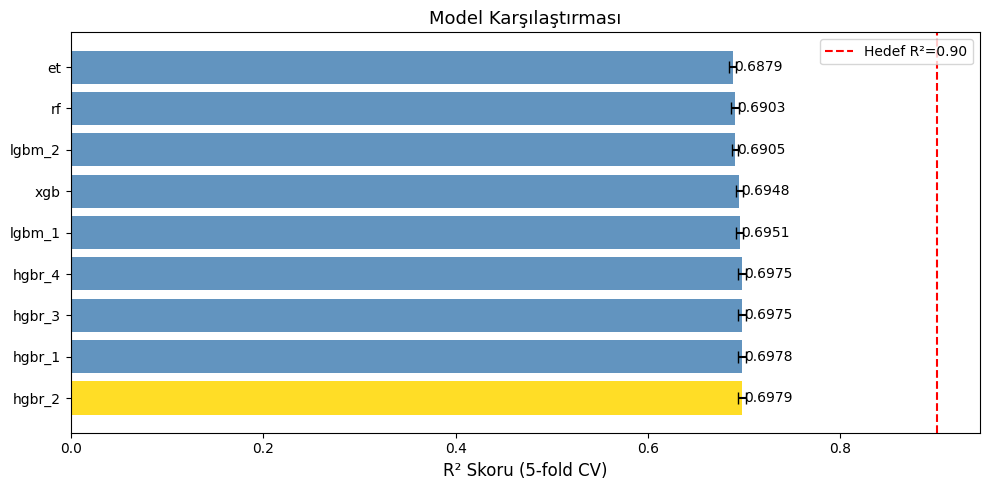

In [ ]:

result_df = (pd.DataFrame(cv_results).T
             .reset_index()
             .rename(columns={'index': 'Model'})
             .sort_values('r2_mean', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gold' if r == result_df['r2_mean'].max()
          else 'steelblue' for r in result_df['r2_mean']]
bars = ax.barh(result_df['Model'], result_df['r2_mean'],
               color=colors, alpha=0.85)
ax.errorbar(result_df['r2_mean'], result_df['Model'],
            xerr=result_df['r2_std'],
            fmt='none', color='black', capsize=4)
ax.set_xlabel('R² Skoru (5-fold CV)', fontsize=12)
ax.set_title('Model Karşılaştırması', fontsize=13)
ax.axvline(0.9, color='red', linestyle='--', label='Hedef R²=0.90')
ax.legend()
for bar, val in zip(bars, result_df['r2_mean']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [35]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print('Optuna mevcut')
except ImportError:
    HAS_OPTUNA = False
    print('Optuna bulunamadı. Varsayılan parametreler kullanılacak.')
    print('Kurulum: pip install optuna')

Optuna mevcut


In [36]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

if HAS_OPTUNA:
    def objective(trial):
        params = dict(
            max_iter          = trial.suggest_int('max_iter', 800, 2000),
            learning_rate     = trial.suggest_float('learning_rate', 0.008, 0.08, log=True),
            max_depth         = trial.suggest_int('max_depth', 5, 10),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 8, 60),
            l2_regularization = trial.suggest_float('l2_regularization', 1e-4, 2.0, log=True),
            max_features      = trial.suggest_float('max_features', 0.4, 1.0),
            max_bins          = trial.suggest_int('max_bins', 128, 255),
        )
        model = HistGradientBoostingRegressor(
            **params,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=25,
            random_state=RANDOM_STATE
        )
        cv_opt = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(
            model, X_arr, y, cv=cv_opt, scoring='r2', n_jobs=-1
        )
        return scores.mean()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
    )
    study.optimize(objective, n_trials=80, show_progress_bar=True)

    print(f"\n En iyi R²  : {study.best_value:.4f}")
    print("En iyi parametreler:")
    for k, v in study.best_params.items():
        print(f"  {k:25s}: {v}")

    BEST_PARAMS = study.best_params
    with open(OUTPUT_DIR / 'best_params.json', 'w') as f:
        json.dump(BEST_PARAMS, f, indent=2)

else:
    BEST_PARAMS = {
        'max_iter': 1500, 'learning_rate': 0.02, 'max_depth': 7,
        'min_samples_leaf': 20, 'l2_regularization': 0.1,
        'max_features': 0.8, 'max_bins': 255
    }
    print("Varsayılan parametreler:", BEST_PARAMS)

  0%|          | 0/80 [00:00<?, ?it/s]


🏆 En iyi R²  : 0.6982
En iyi parametreler:
  max_iter                 : 1443
  learning_rate            : 0.00841694035519207
  max_depth                : 6
  min_samples_leaf         : 60
  l2_regularization        : 0.03327004220150825
  max_features             : 0.4316691375994738
  max_bins                 : 224


In [ ]:

print("Final modeller eğitiliyor (tüm train verisi)...")
final_models = []

for seed_offset in [0, 10, 20]:
    m = HistGradientBoostingRegressor(
        **BEST_PARAMS,
        early_stopping=False,
        random_state=RANDOM_STATE + seed_offset
    )
    m.fit(X_arr, y)
    final_models.append(m)
    print(f"  Seed {RANDOM_STATE + seed_offset} → tamamlandı")

train_preds_avg = np.mean([m.predict(X_arr) for m in final_models], axis=0)
train_r2   = r2_score(y, train_preds_avg)
train_rmse = np.sqrt(mean_squared_error(y, train_preds_avg))
train_mae  = mean_absolute_error(y, train_preds_avg)

print(f"\nTrain Sonuçları:")
print(f"  R²   : {train_r2:.4f}")
print(f"  RMSE : {train_rmse:.4f}")
print(f"  MAE  : {train_mae:.4f}")

Final modeller eğitiliyor (tüm train verisi)...
  Seed 42 → tamamlandı
  Seed 52 → tamamlandı
  Seed 62 → tamamlandı

Train Sonuçları:
  R²   : 0.7318
  RMSE : 1.1558
  MAE  : 0.9223


In [ ]:

print("Final modeller eğitiliyor (tüm train verisi)...")
final_models = []

for seed_offset in [0, 10, 20]:
    m = HistGradientBoostingRegressor(
        **BEST_PARAMS,
        early_stopping=False,
        random_state=RANDOM_STATE + seed_offset
    )
    m.fit(X_arr, y)
    final_models.append(m)
    print(f"  Seed {RANDOM_STATE + seed_offset} → tamamlandı")

train_preds_avg = np.mean([m.predict(X_arr) for m in final_models], axis=0)
train_r2   = r2_score(y, train_preds_avg)
train_rmse = np.sqrt(mean_squared_error(y, train_preds_avg))
train_mae  = mean_absolute_error(y, train_preds_avg)

print(f"\nTrain Sonuçları:")
print(f"  R²   : {train_r2:.4f}")
print(f"  RMSE : {train_rmse:.4f}")
print(f"  MAE  : {train_mae:.4f}")

Final modeller eğitiliyor (tüm train verisi)...
  Seed 42 → tamamlandı
  Seed 52 → tamamlandı
  Seed 62 → tamamlandı

Train Sonuçları:
  R²   : 0.7318
  RMSE : 1.1558
  MAE  : 0.9223


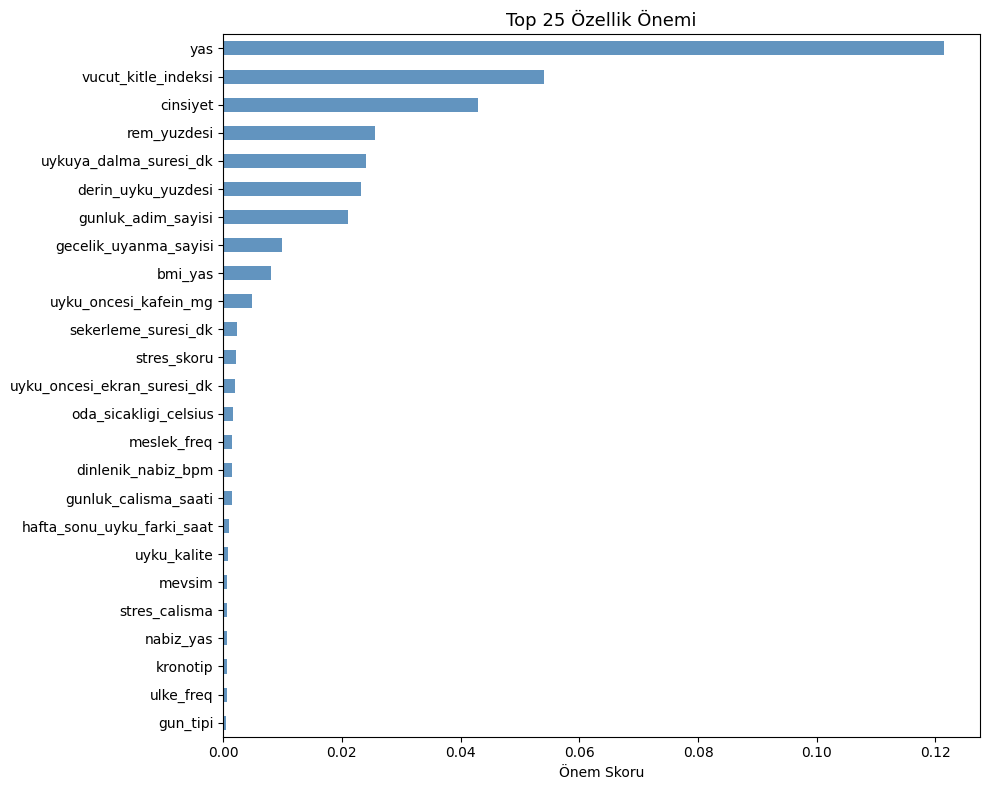

yas                            0.121430
vucut_kitle_indeksi            0.053965
cinsiyet                       0.042887
rem_yuzdesi                    0.025627
uykuya_dalma_suresi_dk         0.024081
derin_uyku_yuzdesi             0.023184
gunluk_adim_sayisi             0.020986
gecelik_uyanma_sayisi          0.009886
bmi_yas                        0.008122
uyku_oncesi_kafein_mg          0.004912
sekerleme_suresi_dk            0.002392
stres_skoru                    0.002098
uyku_oncesi_ekran_suresi_dk    0.001966
oda_sicakligi_celsius          0.001593
meslek_freq                    0.001501


In [40]:
from sklearn.inspection import permutation_importance

X_tr_fi, X_val_fi, y_tr_fi, y_val_fi = train_test_split(
    X_arr, y, test_size=0.15, random_state=RANDOM_STATE
)
final_models[0].fit(X_tr_fi, y_tr_fi)

perm = permutation_importance(
    final_models[0], X_val_fi, y_val_fi,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

fi_series = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 25
fi_series.head(top_n).plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.invert_yaxis()
ax.set_title(f'Top {top_n} Özellik Önemi', fontsize=13)
ax.set_xlabel('Önem Skoru')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print(fi_series.head(15).to_string())

In [ ]:

print("OOF değerlendirme başlıyor...")
print("=" * 60)

cv_main          = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_preds        = np.zeros(len(y))
test_preds_folds = np.zeros((len(X_test_sel), N_FOLDS))

for fold, (train_idx, val_idx) in enumerate(cv_main.split(X_arr)):
    X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
    y_tr, y_val = y[train_idx],     y[val_idx]

    fold_val_preds  = []
    fold_test_preds = []

    for name, model in base_estimators:
        seed_val  = []
        seed_test = []

        for sd in [0, 7, 42]:
            m = clone_model(model, sd, RANDOM_STATE)
            m.fit(X_tr, y_tr)
            seed_val.append(m.predict(X_val))
            seed_test.append(m.predict(X_test_sel.values))

        fold_val_preds.append(np.mean(seed_val,  axis=0))
        fold_test_preds.append(np.mean(seed_test, axis=0))

    oof_preds[val_idx]        = np.mean(fold_val_preds,  axis=0)
    test_preds_folds[:, fold] = np.mean(fold_test_preds, axis=0)

    fold_r2   = r2_score(y_val, oof_preds[val_idx])
    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    print(f"  Fold {fold+1}/{N_FOLDS}  R²={fold_r2:.4f}  RMSE={fold_rmse:.4f}")

test_preds_final = test_preds_folds.mean(axis=1)

oof_r2   = r2_score(y, oof_preds)
oof_rmse = np.sqrt(mean_squared_error(y, oof_preds))
oof_mae  = mean_absolute_error(y, oof_preds)

print("=" * 60)
print(f"OOF R²   : {oof_r2:.4f}")
print(f"OOF RMSE : {oof_rmse:.4f}")
print(f"OOF MAE  : {oof_mae:.4f}")
print(f"test_preds_final üretildi → shape: {test_preds_final.shape}")

OOF değerlendirme başlıyor...
  Fold 1/5  R²=0.6999  RMSE=1.2275
  Fold 2/5  R²=0.6972  RMSE=1.2239
  Fold 3/5  R²=0.7048  RMSE=1.2120
  Fold 4/5  R²=0.6997  RMSE=1.2185
  Fold 5/5  R²=0.6926  RMSE=1.2415
OOF R²   : 0.6988
OOF RMSE : 1.2247
OOF MAE  : 0.9774
✅ test_preds_final üretildi → shape: (24000,)


In [ ]:
test_preds_clipped = np.clip(test_preds_final, 0, 10)

shift = abs(test_preds_clipped.mean() - y.mean())
print(f"Tahmin ort : {test_preds_clipped.mean():.3f}  (Train: {y.mean():.3f})")
print(f"Tahmin std : {test_preds_clipped.std():.3f}   (Train: {y.std():.3f})")
print(f"Kayma      : {shift:.3f} {'Kontrol et!' if shift > 0.3 else 'OK'}")

submission = pd.DataFrame({
    'id'  : test_raw[ID_COL],
    TARGET: test_preds_clipped
})
submission.to_csv(OUTPUT_DIR / 'submission_v3.csv', index=False)
print(f"\nsubmission_v3.csv kaydedildi → {OUTPUT_DIR}/submission_v3.csv")
print(submission.head(10).to_string())

Tahmin ort : 5.941  (Train: 5.913)
Tahmin std : 1.849   (Train: 2.232)
Kayma      : 0.028 ✅ OK

✅ submission_v3.csv kaydedildi → outputs/submission_v3.csv
   id  bilissel_performans_skoru
0   1                   5.863574
1   2                   6.571001
2   3                   3.050233
3   4                   7.232635
4   5                   3.560938
5   6                   5.347803
6   7                   3.471862
7   8                   7.378193
8   9                   3.650123
9  10                   3.610325


In [ ]:
joblib.dump(fe,           OUTPUT_DIR / 'feature_engineer_v3.pkl')
joblib.dump(final_models, OUTPUT_DIR / 'final_models_v3.pkl')

summary = {
    'oof_r2'         : round(float(oof_r2),   4),
    'oof_rmse'       : round(float(oof_rmse),  4),
    'oof_mae'        : round(float(oof_mae),   4),
    'train_r2'       : round(float(train_r2),  4),
    'n_features_raw' : int(X.shape[1]),
    'n_features_sel' : int(X_sel.shape[1]),
    'n_train'        : int(X.shape[0]),
    'n_test'         : int(X_test_sel.shape[0]),
    'n_base_models'  : len(base_estimators),
    'best_params'    : BEST_PARAMS,
    'within_0.5_pct' : round(float((np.abs(y - oof_preds) < 0.5).mean() * 100), 2),
    'within_1.0_pct' : round(float((np.abs(y - oof_preds) < 1.0).mean() * 100), 2),
    'within_2.0_pct' : round(float((np.abs(y - oof_preds) < 2.0).mean() * 100), 2),
}
with open(OUTPUT_DIR / 'model_summary_v3.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("=" * 55)
print("  FINAL SONUÇ — v3")
print("=" * 55)
print(f"  OOF R²           : {oof_r2:.4f}")
print(f"  OOF RMSE         : {oof_rmse:.4f}")
print(f"  OOF MAE          : {oof_mae:.4f}")
print(f"  ±0.5 içinde      : %{summary['within_0.5_pct']}")
print(f"  ±1.0 içinde      : %{summary['within_1.0_pct']}")
print(f"  ±2.0 içinde      : %{summary['within_2.0_pct']}")
print(f"  Kullanılan model : {len(base_estimators)} base × 3 seed")
print(f"  Özellik sayısı   : {X_sel.shape[1]} (seçilmiş)")
print("=" * 55)

  FINAL SONUÇ — v3
  OOF R²           : 0.6988
  OOF RMSE         : 1.2247
  OOF MAE          : 0.9774
  ±0.5 içinde      : %31.78
  ±1.0 içinde      : %58.55
  ±2.0 içinde      : %89.83
  Kullanılan model : 9 base × 3 seed
  Özellik sayısı   : 88 (seçilmiş)


In [ ]:
def predict_bilissel_performans(
    input_df,
    fe_path    = 'outputs/feature_engineer_v3.pkl',
    models_path= 'outputs/final_models_v3.pkl'
):
    fe_loaded     = joblib.load(fe_path)
    models_loaded = joblib.load(models_path)
    X_inp  = fe_loaded.transform(input_df)
    X_inp  = X_inp[good_features] if set(good_features).issubset(X_inp.columns) else X_inp
    preds  = np.mean([m.predict(X_inp.values) for m in models_loaded], axis=0)
    return np.clip(preds, 0, 10)

sample       = test_raw.head(5).copy()
sample_preds = predict_bilissel_performans(sample)
print("Örnek tahminler:", np.round(sample_preds, 4))

Örnek tahminler: [5.9114 6.456  2.9458 7.1395 3.526 ]
